In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


In [18]:


# Seed set taake sab ke paas same random numbers aayein
np.random.seed(42)
n = 200 # 200 employees ka data

# 1. NumPy se Fake Columns Banayein
satisfaction = np.random.uniform(0.1, 1.0, n)            # 0.1 se 1.0 ke beech floats
monthly_hours = np.random.randint(90, 300, n)            # 90 se 300 hours
projects = np.random.randint(1, 10, n)                   # 1 se 10 projects
dept = np.random.choice(['Sales', 'IT', 'HR'], n)        # Random Departments

# Target 1 (Continuous Number for Regression): Performance Score
performance = 50 + (satisfaction * 30) + (projects * 2)

# Target 2 (0/1 Category for Classification): Will Leave
# Agar satisfaction kam ho (< 0.4) aur hours zyada hon (> 200) toh 1 (Chor dega)
will_leave = np.where((satisfaction < 0.4)   & (monthly_hours > 200), 1, 0)

# 2. Pandas DataFrame Banayein
df_raw = pd.DataFrame({
    'Satisfaction': satisfaction,
    'Monthly_Hours': monthly_hours,
    'Projects': projects,
    'Department': dept,
    'Performance_Score': performance,
    'Will_Leave': will_leave
})

# 3. File Handling: CSV File mein save karein
df_raw.to_csv('employee_data.csv', index=False)
print("File 'employee_data.csv' successfully saved!")

# 4. CSV File ko wapas Load karke dekhein
df = pd.read_csv('employee_data.csv')
df.head()

File 'employee_data.csv' successfully saved!


,Satisfaction,Monthly_Hours,Projects,Department,Performance_Score,Will_Leave
0,0.437086,241,9,IT,81.112583,0
1,0.955643,205,8,HR,94.669286,0
2,0.758795,164,5,Sales,82.763836,0
3,0.638793,202,1,HR,71.163779,0
4,0.240417,289,7,Sales,71.212503,1


In [19]:
df_encoded = pd.get_dummies(df, columns=['Department'], drop_first=True)

X = df_encoded.drop(columns=['Performance_Score', 'Will_Leave'])
y_reg = df_encoded['Performance_Score']  # Regression Target
y_class =   df_encoded['Will_Leave']  # Classification Target

print("Features (X) k columns : ")
print(X.columns.tolist())


Features (X) k columns : 
['Satisfaction', 'Monthly_Hours', 'Projects', 'Department_IT', 'Department_Sales']


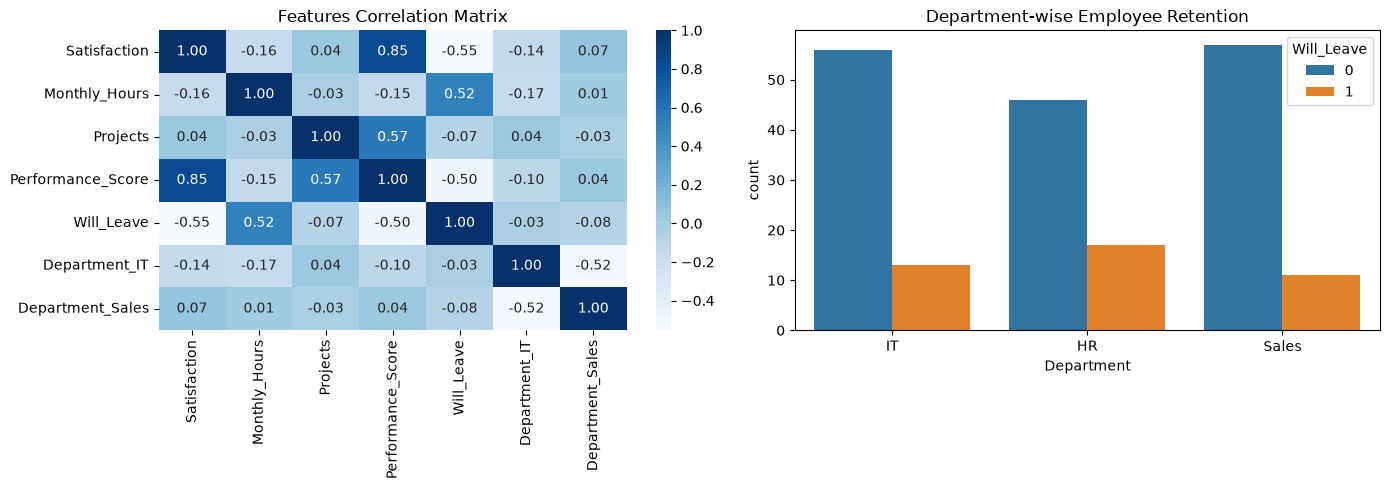

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Figure ka size set karein (Width, Height)
plt.figure(figsize=(14, 5))

# -------------------------------------------------------------
# Chart 1: Heatmap (Correlation dekhne ke liye)
# -------------------------------------------------------------
plt.subplot(1, 2, 1) # 1 row, 2 columns grid -> Chart 1
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f", cmap='Blues')
plt.title('Features Correlation Matrix')

# -------------------------------------------------------------
# Chart 2: Countplot (Retention rate dekhne ke liye)
# -------------------------------------------------------------
plt.subplot(1, 2, 2) # 1 row, 2 columns grid -> Chart 2
sns.countplot(data=df, x='Department', hue='Will_Leave')
plt.title('Department-wise Employee Retention')

plt.tight_layout()
plt.show()

In [21]:
# 1. Regression Split
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# 2. Classification Split (sirf target y_class ko split karein)
_, _, y_class_train, y_class_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Verify Shapes
print("Training Features Shape:", X_train.shape)
print("Regression Target Train Shape:", y_reg_train.shape)
print("Classification Target Train Shape:", y_class_train.shape)

Training Features Shape: (160, 5)
Regression Target Train Shape: (160,)
Classification Target Train Shape: (160,)


In [22]:
# Linear Regression
model = LinearRegression()
model.fit(X_train, y_reg_train)
score = r2_score(y_reg_test, model.predict(X_test))
print("Linear Regression R2 Score:", score)

# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=4, random_state=42)
rf_reg.fit(X_train, y_reg_train)  # <--- y_reg_train use karein
r2_score_rf = r2_score(y_reg_test, rf_reg.predict(X_test)) # <--- y_reg_test use karein
print("Random Forest R2 Score:", r2_score_rf)

Linear Regression R2 Score: 1.0
Random Forest R2 Score: 0.9646218093491544


In [23]:
print("--classification methods--")
# Logistic Regression
log_reg =  LogisticRegression(max_iter = 1000)
log_reg.fit(X_train, y_class_train)  # <--- y_class_train use karein
y_pred_log = log_reg.predict(X_test)  # <--- X_test use karein
accuracy_log = accuracy_score(y_class_test, y_pred_log)  # <--- y_class_test use karein/
print("Logistic Regression Accuracy:", accuracy_log)

dt_class = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_class.fit(X_train, y_class_train)
y_pred_dt = dt_class.predict(X_test)
accuracy_dt = accuracy_score(y_class_test, y_pred_dt)
print("Decision Tree Accuracy:", accuracy_dt)


rf_class = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42)
rf_class.fit(X_train, y_class_train)
y_pred_rf = rf_class.predict(X_test)
accuracy_rf = accuracy_score(y_class_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)


--classification methods--
Logistic Regression Accuracy: 0.975
Decision Tree Accuracy: 0.95
Random Forest Accuracy: 0.95


In [26]:
import pandas as pd
import numpy as np

print("--- CELL 8: PREDICTION FOR A NEW EMPLOYEE ---")

# 1. Pehle X_train ke saare columns ko 0 se initialize kar lein (Taake exact match bane)
new_emp_df = pd.DataFrame(0, index=[0], columns=X_train.columns)

# 2. Ab specific values set karein (Jo columns aap test karna chahte hain)
new_emp_df['Satisfaction'] = 0.25      # Low satisfaction (25%)
new_emp_df['Projects'] = 6              # High number of projects
new_emp_df['Monthly_Hours'] = 260       # Overworked (260 hours/month)

# Agar Department_IT column aap ke X_train mein majood hai, toh isay 1 kar dein:
if 'Department_IT' in new_emp_df.columns:
    new_emp_df['Department_IT'] = 1

# -------------------------------------------------------------
# 3. Performance Score Predict Karein (Linear Regression)
# -------------------------------------------------------------
predicted_performance = model.predict(new_emp_df)[0]

# -------------------------------------------------------------
# 4. Retention Predict Karein (Logistic Regression)
# -------------------------------------------------------------
predicted_leave_status = log_reg.predict(new_emp_df)[0]
predicted_leave_prob = log_reg.predict_proba(new_emp_df)[0][1]

# -------------------------------------------------------------
# 5. Output Print Karein
# -------------------------------------------------------------
print("\n📊 --- PREDICTION RESULTS ---")
print(f"Predicted Performance Score : {predicted_performance:.2f} / 100")

if predicted_leave_status == 1:
    print(f"Retention Warning           : ⚠️ High Risk! Employee is LIKELY TO LEAVE (Risk Probability: {predicted_leave_prob * 100:.1f}%)")
else:
    print(f"Retention Status            : ✅ Safe! Employee is LIKELY TO STAY (Risk Probability: {predicted_leave_prob * 100:.1f}%)")

--- CELL 8: PREDICTION FOR A NEW EMPLOYEE ---

📊 --- PREDICTION RESULTS ---
Predicted Performance Score : 69.50 / 100
Retention Warning           : ⚠️ High Risk! Employee is LIKELY TO LEAVE (Risk Probability: 70.8%)
